Epoch 1/5
1875/1875 [==============================] - 8s 3ms/step - loss: 0.6508 - accuracy: 0.8397
Epoch 2/5
1875/1875 [==============================] - 6s 3ms/step - loss: 0.3332 - accuracy: 0.9077
Epoch 3/5
1875/1875 [==============================] - 5s 3ms/step - loss: 0.2827 - accuracy: 0.9206
Epoch 4/5
1875/1875 [==============================] - 6s 3ms/step - loss: 0.2518 - accuracy: 0.9297
Epoch 5/5
313/313 [==============================] - 1s 4ms/step - loss: 0.2122 - accuracy: 0.9403
Test accuracy: 94.02999877929688 %
313/313 [==============================] - 1s 2ms/step


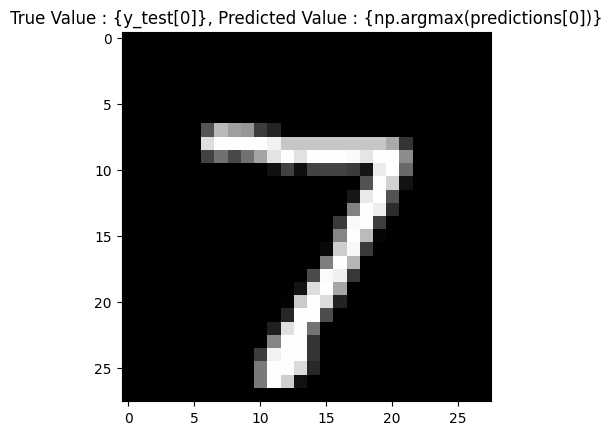

In [2]:
import tensorflow as tf
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
# Load and preprocess the MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255
model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# 1. Create a TensorBoard callback
tb_callback = tf.keras.callbacks.TensorBoard(log_dir='./logs/sgd')

model.compile(optimizer='SGD',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 2. Train model with TensorBoard callback
model.fit(x_train, y_train, epochs=5, callbacks=[tb_callback])

test_loss, test_accuracy = model.evaluate(x_test, y_test)
print("Test accuracy:", test_accuracy * 100, "%")

predictions = model.predict(x_test)

plt.imshow(x_test[0], cmap='gray')
plt.title("True Value : {y_test[0]}, Predicted Value : {np.argmax(predictions[0])}")
plt.show()



In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_train, x_test = x_train / 255.0, x_test / 255.0

model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# 1. Create a TensorBoard callback
tb_callback = tf.keras.callbacks.TensorBoard(log_dir='./logs/adam')

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 2. Train model with TensorBoard callback
model.fit(x_train, y_train, epochs=5, callbacks=[tb_callback])

test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_accuracy * 100:.2f}%")

predictions = model.predict(x_test)

plt.imshow(x_test[0], cmap='gray')
plt.title("True Value : {y_test[0]}, Predicted Value : {np.argmax(predictions[0])}")
plt.show()


KeyboardInterrupt: 

In [5]:
import tensorflow as tf

# Model without BatchNorm/Dropout
def create_cnn():
    model = tf.keras.models.Sequential([
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu', strides=2, input_shape=(28, 28, 1)),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu', strides=2),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model



Epoch 1/5
938/938 [==============================] - 12s 4ms/step - loss: 0.1889 - accuracy: 0.9438 - val_loss: 0.0793 - val_accuracy: 0.9768
Epoch 2/5
938/938 [==============================] - 3s 4ms/step - loss: 0.0571 - accuracy: 0.9825 - val_loss: 0.0437 - val_accuracy: 0.9854
Epoch 3/5
938/938 [==============================] - 3s 4ms/step - loss: 0.0364 - accuracy: 0.9885 - val_loss: 0.0398 - val_accuracy: 0.9852
Epoch 4/5
938/938 [==============================] - 3s 4ms/step - loss: 0.0258 - accuracy: 0.9919 - val_loss: 0.0383 - val_accuracy: 0.9876
Epoch 5/5
938/938 [==============================] - 3s 4ms/step - loss: 0.0189 - accuracy: 0.9935 - val_loss: 0.0339 - val_accuracy: 0.9876
Epoch 1/5
938/938 [==============================] - 5s 5ms/step - loss: 0.1274 - accuracy: 0.9619 - val_loss: 0.0600 - val_accuracy: 0.9814
Epoch 2/5
938/938 [==============================] - 5s 5ms/step - loss: 0.0441 - accuracy: 0.9863 - val_loss: 0.0563 - val_accuracy: 0.9812
Epoch 3/5
93

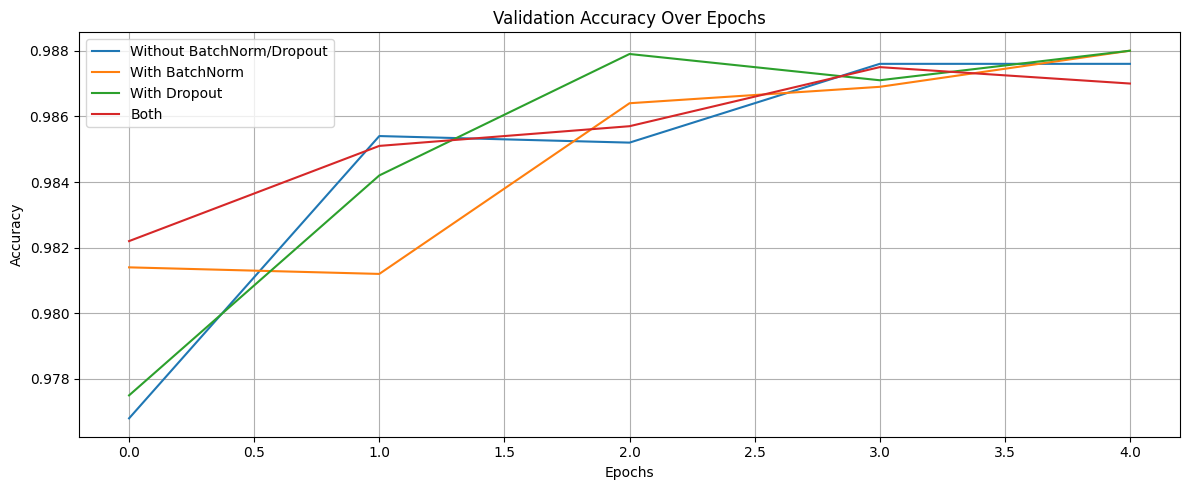

In [4]:
import tensorflow as tf

# Model without BatchNorm/Dropout
def create_cnn():
    model = tf.keras.models.Sequential([
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu', strides=2, input_shape=(28, 28, 1)),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu', strides=2),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# Model with BatchNormalization
def create_batchnorm_cnn():
    model = tf.keras.models.Sequential([
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu', strides=2, input_shape=(28, 28, 1)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu', strides=2),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


# Model with Dropout
def create_dropout_cnn():
    model = tf.keras.models.Sequential([
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu', strides=2, input_shape=(28, 28, 1)),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu', strides=2),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.5),  # 50% dropout
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# Model with both BatchNormalization and Dropout
def create_batchnorm_dropout_cnn():
    model = tf.keras.models.Sequential([
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu', strides=2, input_shape=(28, 28, 1)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu', strides=2),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.5),  # 50% dropout
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# Load data
(X_train, Y_train), (X_test, Y_test) = tf.keras.datasets.mnist.load_data()
X_train = X_train.reshape(-1, 28, 28, 1).astype("float32") / 255.0
X_test = X_test.reshape(-1, 28, 28, 1).astype("float32") / 255.0

# Train all models
cnn = create_cnn()
cnn_history = cnn.fit(X_train, Y_train, validation_data=(X_test, Y_test), epochs=5, batch_size=64)

batchnorm_cnn = create_batchnorm_cnn()
batchnorm_history = batchnorm_cnn.fit(X_train, Y_train, validation_data=(X_test, Y_test), epochs=5, batch_size=64)

dropout_cnn = create_dropout_cnn()
dropout_history = dropout_cnn.fit(X_train, Y_train, validation_data=(X_test, Y_test), epochs=5, batch_size=64)

batchnorm_dropout_cnn = create_batchnorm_dropout_cnn()
batchnorm_dropout_history = batchnorm_dropout_cnn.fit(X_train, Y_train, validation_data=(X_test, Y_test), epochs=5, batch_size=64)




import matplotlib.pyplot as plt

def plot_training_results(histories, labels):
    plt.figure(figsize=(12, 5))
    for i, history in enumerate(histories):
        plt.plot(history.history['val_accuracy'], label=labels[i])
    plt.title("Validation Accuracy Over Epochs")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Call plotting function
plot_training_results(
    [cnn_history, batchnorm_history, dropout_history, batchnorm_dropout_history],
    ["Without BatchNorm/Dropout", "With BatchNorm", "With Dropout", "Both"]
)
